# Actividad 2_10: Repaso

En esta Actividad vamos a repasar los conceptos que hemos visto hasta ahora en clase.

Descarga el archivo "Top 100 Cryptocurrency 2022.csv" que se adjunta con la tarea y realiza los siguientes apartados:

Debes escribir una programa que realice las siguientes tareas:

1. Importar los datos del dataset adjunto con la tarea y guardarlos en un DataFrame.
2. Crea una función que reciba un número (debes tratar la excepción en caso de que no sea un entero) y el dataframe y devuelva un DataFrame en el que haya eliminado todas las criptomonedas que no superen el número pasado como parámetro. Prueba la función.
3. Normaliza la columna del precio actual de las criptomonedas ("Price") y muestre una gráfica con los valores de las 10 que tienen mayor valor.
4. Predice el próximo valor de las criptomonedas suponiendo que la variación de las próximas 24h  va a ser la misma que en las anteriores ('Changes 24H') y mételo en una columna nueva.

In [1]:
import pandas as pd

df = pd.read_csv("Top 100 Cryptocurrency 2022.csv")
df.head(100)

,Ranking,Crypto Name,Price,Changes 24H,Changes 7D,Changes 30D,Changes 1Y,Market Cap,Volume 24H,Available Supply
0,1,BITCOIN,"$36,983",-2.97%,1.96%,-20.08%,8.25%,$701.49 B,$13.01 B,18.94 M BTC
1,2,WRAPPED BITCOIN,"$37,019",-2.84%,1.84%,-20.13%,8.26%,$10.04 B,$253.14 M,271.16 K WBTC
2,3,HUOBI BTC,"$36,942",-4.24%,1.37%,-20.39%,7.82%,$1.47 B,$29.51 M,39.88 K HBTC
3,4,ETHEREUM,"$2,510",-3.64%,-1.28%,-32.04%,82.54%,$298.87 B,$10.00 B,119.38 M ETH
4,5,LIDO STAKED ETHER,"$2,494",-3.23%,-1.84%,-31.98%,95.88%,$4.48 B,$2.07 M,1.79 M STETH
...,...,...,...,...,...,...,...,...,...,...
95,96,ECOMI,$0.01,-6.53%,4.42%,9.77%,9999.99%,$3.99 B,$4.01 M,581.91 B OMI
96,97,BITTORRENT,$0.00,$0.00,-1.10%,-19.83%,481.49%,$2.04 B,$283.87 K,932.50 B BTTOLD
97,98,SAFEMOON,$0.00,-3.19%,-3.72%,-34.03%,0.00%,$933.63 M,$410.28 K,566.50 B SFM
98,99,ECASH,$0.00,-3.71%,-1.41%,-32.83%,0.00%,$1.40 B,$19.78 M,18.97 T XEC


In [ ]:

# Quitar espacios en blanco en todas las columnas
df.columns = df.columns.str.strip()

# Limpiar los filas
df["Price"] = df["Price"].astype(str).str.replace("$", "").str.replace(",", "").str.replace("\"", "").astype(float)
df["Changes 24H"] = df["Changes 24H"].astype(str).str.replace("$", "").str.replace("%", "").str.replace(",", "").astype(float)

name = []
price = []
changes = []

def recibir_num(num, df):
    try:
        num = float(num)

        # Comprobrar que Price sea menos que num
        filtrado_mayor = df[df["Price"] > num]
        filtrado_menor = df[df["Price"] < num]

        name = filtrado_menor["Crypto Name"].tolist()
        price = filtrado_menor["Price"].tolist()
        changes = filtrado_menor["Changes 24H"].tolist()

        # Dataframe con los eliminados
        df_eliminados = pd.DataFrame ({
            "Crypto Name": name,
            "Price": price,
            "Changes 24H": changes
        })

        return filtrado_mayor.head(100)

    except ValueError:
        print("ERROR: num debe ser numérico")

df_norm = recibir_num(1000.0, df)
recibir_num(1000.0, df)




,Ranking,Crypto Name,Price,Changes 24H,Changes 7D,Changes 30D,Changes 1Y,Market Cap,Volume 24H,Available Supply,Predicted Price
0,1,BITCOIN,36983.0,-2.97,1.96%,-20.08%,8.25%,$701.49 B,$13.01 B,18.94 M BTC,35884.6049
1,2,WRAPPED BITCOIN,37019.0,-2.84,1.84%,-20.13%,8.26%,$10.04 B,$253.14 M,271.16 K WBTC,35967.6604
2,3,HUOBI BTC,36942.0,-4.24,1.37%,-20.39%,7.82%,$1.47 B,$29.51 M,39.88 K HBTC,35375.6592
3,4,ETHEREUM,2510.0,-3.64,-1.28%,-32.04%,82.54%,$298.87 B,$10.00 B,119.38 M ETH,2418.6360
4,5,LIDO STAKED ETHER,2494.0,-3.23,-1.84%,-31.98%,95.88%,$4.48 B,$2.07 M,1.79 M STETH,2413.4438
5,6,MAKER,1989.0,1.58,7.24%,-15.86%,24.94%,$1.78 B,$49.99 M,901.31 K MKR,2020.4262


In [60]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

escalador = MinMaxScaler()

df_norm[["Price", "Changes 24H"]] = escalador.fit_transform(df_norm[["Price", "Changes 24H"]])

df_norm.head()

,Ranking,Crypto Name,Price,Changes 24H,Changes 7D,Changes 30D,Changes 1Y,Market Cap,Volume 24H,Available Supply,Predicted Price
0,1,BITCOIN,0.998972,0.218213,1.96%,-20.08%,8.25%,$701.49 B,$13.01 B,18.94 M BTC,35884.6049
1,2,WRAPPED BITCOIN,1.000000,0.240550,1.84%,-20.13%,8.26%,$10.04 B,$253.14 M,271.16 K WBTC,35967.6604
2,3,HUOBI BTC,0.997802,0.000000,1.37%,-20.39%,7.82%,$1.47 B,$29.51 M,39.88 K HBTC,35375.6592
3,4,ETHEREUM,0.014873,0.103093,-1.28%,-32.04%,82.54%,$298.87 B,$10.00 B,119.38 M ETH,2418.6360
4,5,LIDO STAKED ETHER,0.014416,0.173540,-1.84%,-31.98%,95.88%,$4.48 B,$2.07 M,1.79 M STETH,2413.4438


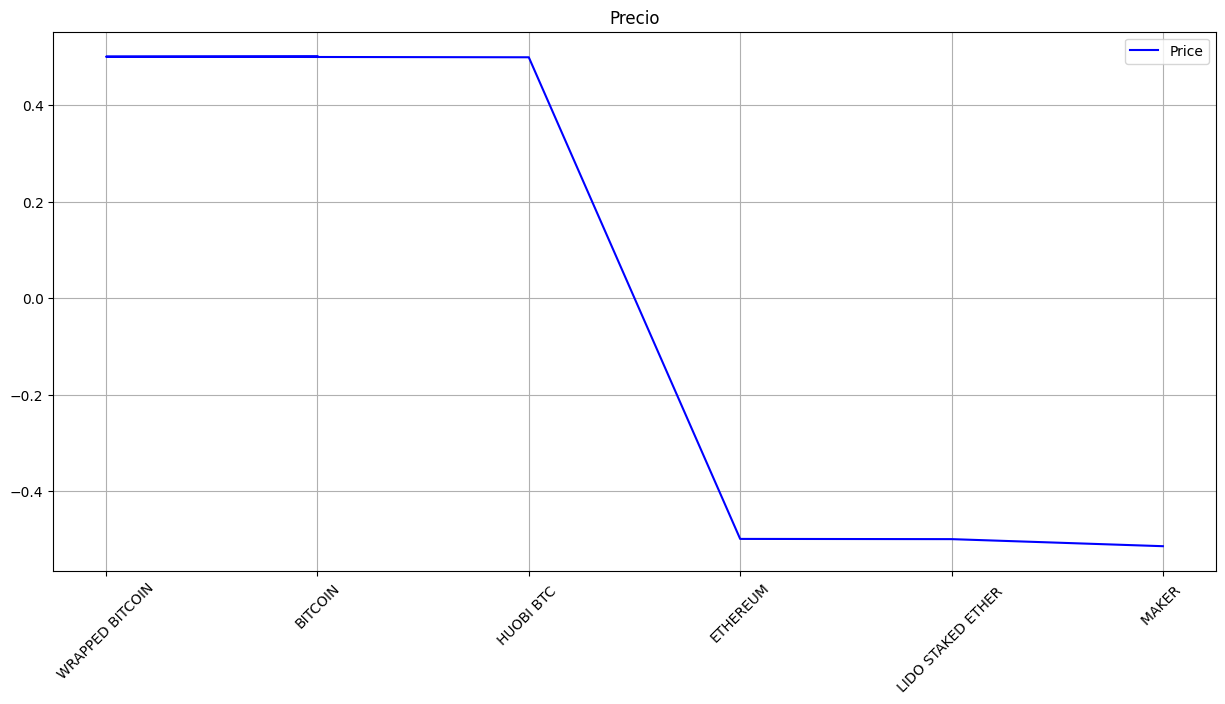

In [54]:
import matplotlib.pyplot as plt

top10_prices = df_norm.sort_values(by="Price", ascending=False).head(10)
top10_prices.head(100)

plt.figure(figsize=(15,7))

plt.plot(top10_prices["Price"], label="Price", color="blue")

plt.xticks(ticks=range(len(top10_prices)), labels=top10_prices["Crypto Name"], rotation=45)

plt.title("Precio")
plt.xlabel("")
plt.ylabel("")
plt.legend()
plt.grid(True)
plt.show()





In [ ]:
# Predice el próximo valor de las criptomonedas suponiendo que la variación de las próximas 24h  va a ser la misma que en las anteriores
df["Predicted Price"] = df["Price"] * (1 + df["Changes 24H"] / 100)
df.head()

,Ranking,Crypto Name,Price,Changes 24H,Changes 7D,Changes 30D,Changes 1Y,Market Cap,Volume 24H,Available Supply,Predicted Price
0,1,BITCOIN,36983.0,-2.97,1.96%,-20.08%,8.25%,$701.49 B,$13.01 B,18.94 M BTC,35884.6049
1,2,WRAPPED BITCOIN,37019.0,-2.84,1.84%,-20.13%,8.26%,$10.04 B,$253.14 M,271.16 K WBTC,35967.6604
2,3,HUOBI BTC,36942.0,-4.24,1.37%,-20.39%,7.82%,$1.47 B,$29.51 M,39.88 K HBTC,35375.6592
3,4,ETHEREUM,2510.0,-3.64,-1.28%,-32.04%,82.54%,$298.87 B,$10.00 B,119.38 M ETH,2418.6360
4,5,LIDO STAKED ETHER,2494.0,-3.23,-1.84%,-31.98%,95.88%,$4.48 B,$2.07 M,1.79 M STETH,2413.4438
